In [1]:
import cv2 
import mediapipe as mp


In [2]:
from mediapipe.tasks.python import vision
from mediapipe.tasks import python as mp_python
import mediapipe as mp

In [ ]:
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles =mp.solutions.drawing_styles
mp_drawing_specs = mp_drawing.DrawingSpec(color = (0,255,0), thickness =1)


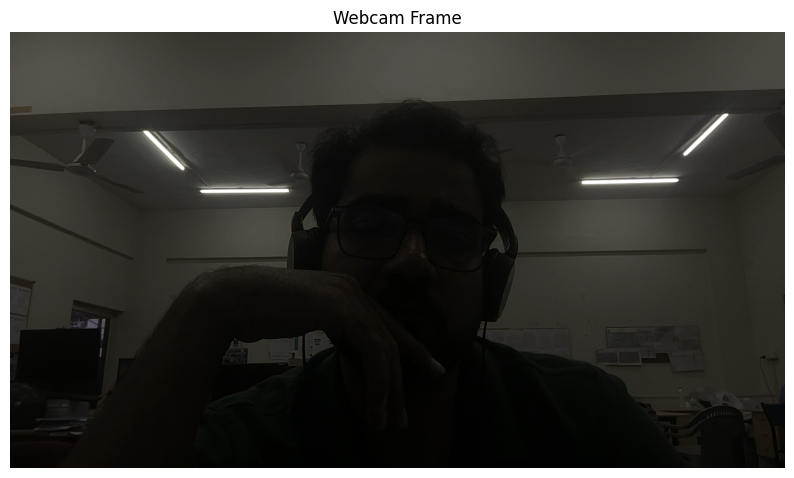

In [ ]:
cap = cv2.VideoCapture(0)
mp_face_mesh = mp.solutions.face_mesh
with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks = True,
    min_detection_confidence =0.5,
    min_tracking_confidence = 0.5
) as face_mesh:
    while cap.isOpened():
        success, image = cap.read()
        if not success:
            break
        results= face_mesh.process(image)
        for face_landmarks in results.multi_face_landmakers:
            mp_drawing.draw_landmarks(
                image= image,
                landmark_list = face_landmarks,
                connections= mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec= None,
                connection_drawing_spec = mp_drawing_styles
                .get_default_face_mesh_tesselation_style()

            )
            mp_drawing.draw_landmarks(
                image= image,
                landmark_list = face_landmarks,
                connections= mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec= None,
                connection_drawing_spec = mp_drawing_specs
                    .get_default_face_mesh_contours_style()

            )

        
        cv2.imshow("My video capture", cv2.flip(image,1))
        if cv2.waitKey(100)== ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

: 

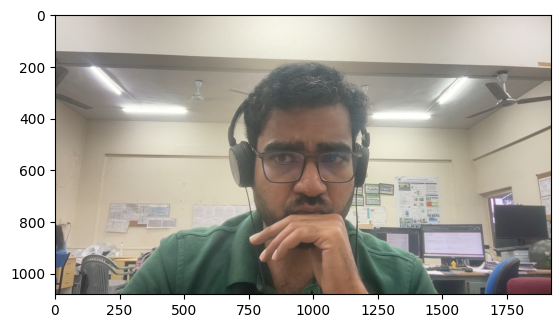

In [3]:
#an expriment
success, image = cap.read()
if success:
    # Display using matplotlib instead
    import matplotlib.pyplot as plt
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()
cap.release()